In [3]:
from utils import *

# 1. MLP

## Flatten

As imagens chegam ao modelo como tensores de dimensão (batch, 3, 64, 64).
O MLP não processa dados espaciais — requer um vector 1D por imagem.
O nn.Flatten() converte cada imagem em (batch, 12288), onde 12288 = 3 × 64 × 64.
Toda a informação espacial é destruída — esta é a limitação fundamental do MLP
face à CNN, que preserva a estrutura 2D.

In [ ]:
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, accuracy_score

In [ ]:
model_A = nn.Sequential(
    nn.Flatten(),
    nn.Linear(12288, 256),
    nn.ReLU(),
    nn.Linear(256, 75)
)

model_B = nn.Sequential(
    nn.Flatten(),
    nn.Linear(12288, 512),
    nn.ReLU(),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Linear(256, 75)
)

model_C = nn.Sequential(
    nn.Flatten(),
    nn.Linear(12288, 1024),
    nn.ReLU(),
    nn.Linear(1024, 512),
    nn.ReLU(),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Linear(256, 75)
)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model_A = model_A.to(device)
model_B = model_B.to(device)
model_C = model_C.to(device)

print(f"Arq A: {sum(p.numel() for p in model_A.parameters()):,} parâmetros")
print(f"Arq B: {sum(p.numel() for p in model_B.parameters()):,} parâmetros")
print(f"Arq C: {sum(p.numel() for p in model_C.parameters()):,} parâmetros")

Device: cpu
Arq A: 3,165,259 parâmetros
Arq B: 6,442,571 parâmetros
Arq C: 13,259,339 parâmetros


In [ ]:
def trainModel(model, optimizer, loss_fn, train_loader, val_loader, num_epochs, device):
    
    train_losses = []
    val_losses = []
    
    for epoch in range(num_epochs):

        # Treino
        model.train()
        train_loss = 0.0
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            y_pred = model(images)
            loss = loss_fn(y_pred, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
        
        train_loss /= len(train_loader)
        train_losses.append(train_loss)
        
        # Validação
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)
                
                y_pred = model(images)
                loss = loss_fn(y_pred, labels)
                val_loss += loss.item()
            
        val_loss /= len(val_loader)
        val_losses.append(val_loss)
        
        if epoch % 5 == 0:
            print(f"Epoch {epoch}/{num_epochs} — Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
            
    return train_losses, val_losses

In [ ]:
def evaluate(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            
            y_pred = model(images)
            preds = torch.argmax(y_pred, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    
    return acc, f1

In [ ]:
NUM_EPOCHS = 20
LR = 1e-3
results = []
EXP_COUNTER = [0]  # contador automático de experiências

## Arquitetura B

In [ ]:
def create_model_B():
    return nn.Sequential(
        nn.Flatten(),
        nn.Linear(12288, 512), 
        nn.ReLU(),
        nn.Linear(512, 256), 
        nn.ReLU(),
        nn.Linear(256, 75)
    ).to(device)

def run_experiment(model_fn, loss_fn_cls, optimizer_fn, results,
                   arq='B', dropout='-', batchnorm='-',
                   weightdecay='-', earlystop='-', normalize='-', notas=''):
    EXP_COUNTER[0] += 1
    exp = f"{arq}{EXP_COUNTER[0]}"
    
    model = model_fn()
    loss_fn = loss_fn_cls()
    optimizer = optimizer_fn(model)
    
    loss_name = loss_fn_cls.__name__.replace('Loss', '')
    opt_name = optimizer.__class__.__name__
    lr = optimizer.param_groups[0]['lr']
    
    train_l, val_l = trainModel(model, optimizer, loss_fn, train_loader, val_loader, NUM_EPOCHS, device)
    acc, f1 = evaluate(model, val_loader, device)
    
    results.append({
        'exp': exp, 'arquitectura': arq,
        'loss': loss_name, 'optimizer': opt_name,
        'LR': lr, 'epochs': NUM_EPOCHS,
        'dropout': dropout, 'BatchNorm': batchnorm,
        'WeightDecay': weightdecay, 'EarlyStop': earlystop,
        'Normalize': normalize,
        'F1-macro': round(f1, 4), 'acc': round(acc, 4),
        'notas': notas
    })
    print(f"{exp} — {loss_name} + {opt_name} — Acc: {acc:.4f} | F1: {f1:.4f}")
    return model, train_l, val_l

In [ ]:
model_B1, train_losses_B1, val_losses_B1 = run_experiment(
    model_fn=create_model_B,
    loss_fn_cls=nn.CrossEntropyLoss,
    optimizer_fn=lambda m: torch.optim.Adam(m.parameters(), lr=LR),
    results=results,
    # dropout='0.3',        # adicionar nn.Dropout(0.3) ao create_model_B
    # batchnorm='True',     # adicionar nn.BatchNorm1d ao create_model_B
    # weightdecay='1e-4',   # optimizer_fn=lambda m: torch.optim.Adam(m.parameters(), lr=LR, weight_decay=1e-4)
    # earlystop='5',        # patience=5 no trainModel
    # normalize='True',     # usar transform com Normalize(RGB_MEAN, RGB_STD)
    notas='baseline'
)

Epoch 0/20 — Train Loss: 4.2680 | Val Loss: 4.0209
Epoch 5/20 — Train Loss: 2.8822 | Val Loss: 3.0712
Epoch 10/20 — Train Loss: 2.2927 | Val Loss: 2.7593
Epoch 15/20 — Train Loss: 1.8579 | Val Loss: 2.8314
B1 — CrossEntropy + Adam — Acc: 0.3048 | F1: 0.2862


In [ ]:
model_B2, train_losses_B2, val_losses_B2 = run_experiment(
    model_fn=create_model_B,
    loss_fn_cls=nn.MultiMarginLoss,
    optimizer_fn=lambda m: torch.optim.Adam(m.parameters(), lr=LR),
    results=results
)

Epoch 0/20 — Train Loss: 0.8047 | Val Loss: 0.5259
Epoch 5/20 — Train Loss: 0.2380 | Val Loss: 0.2921
Epoch 10/20 — Train Loss: 0.1498 | Val Loss: 0.2546
Epoch 15/20 — Train Loss: 0.0789 | Val Loss: 0.2588
B2 — MultiMargin + Adam — Acc: 0.2904 | F1: 0.2798


In [ ]:
model_B3, train_losses_B3, val_losses_B3 = run_experiment(
    model_fn=create_model_B,
    loss_fn_cls=nn.CrossEntropyLoss,
    optimizer_fn=lambda m: torch.optim.RMSprop(m.parameters(), lr=LR),
    results=results
)

Epoch 0/20 — Train Loss: 5.8571 | Val Loss: 3.8654
Epoch 5/20 — Train Loss: 3.0089 | Val Loss: 2.9934
Epoch 10/20 — Train Loss: 2.5144 | Val Loss: 2.8975
Epoch 15/20 — Train Loss: 2.1977 | Val Loss: 3.0748
B3 — CrossEntropy + RMSprop — Acc: 0.2827 | F1: 0.2620


In [ ]:
model_B4, train_losses_B4, val_losses_B4 = run_experiment(
    model_fn=create_model_B,
    loss_fn_cls=nn.MultiMarginLoss,
    optimizer_fn=lambda m: torch.optim.RMSprop(m.parameters(), lr=LR),
    results=results
)

Epoch 0/20 — Train Loss: 1.0522 | Val Loss: 0.5354
Epoch 5/20 — Train Loss: 0.2902 | Val Loss: 0.3164
Epoch 10/20 — Train Loss: 0.1885 | Val Loss: 0.2905
Epoch 15/20 — Train Loss: 0.1337 | Val Loss: 0.2694
B4 — MultiMargin + RMSprop — Acc: 0.2529 | F1: 0.2304


## Arquitetura A

In [ ]:
def create_model_A():
    return nn.Sequential(
        nn.Flatten(),
        nn.Linear(12288, 256),
        nn.ReLU(),
        nn.Linear(256, 75)
    ).to(device)

## Arquitetura C

In [ ]:
def create_model_C():
    return nn.Sequential(
        nn.Flatten(),
        nn.Linear(12288, 1024),
        nn.ReLU(),
        nn.Linear(1024, 512),
        nn.ReLU(),
        nn.Linear(512, 256),
        nn.ReLU(),
        nn.Linear(256, 75)
    ).to(device)

## Análise

In [ ]:
# Tabela resultados
print(pd.DataFrame(results))

  exp arquitectura          loss optimizer     LR  epochs dropout BatchNorm  \
0  B1            B  CrossEntropy      Adam  0.001      20       -         -   
1  B2            B   MultiMargin      Adam  0.001      20       -         -   
2  B3            B  CrossEntropy   RMSprop  0.001      20       -         -   
3  B4            B   MultiMargin   RMSprop  0.001      20       -         -   

  WeightDecay EarlyStop Normalize  F1-macro     acc     notas  
0           -         -         -    0.2862  0.3048  baseline  
1           -         -         -    0.2798  0.2904            
2           -         -         -    0.2620  0.2827            
3           -         -         -    0.2304  0.2529            


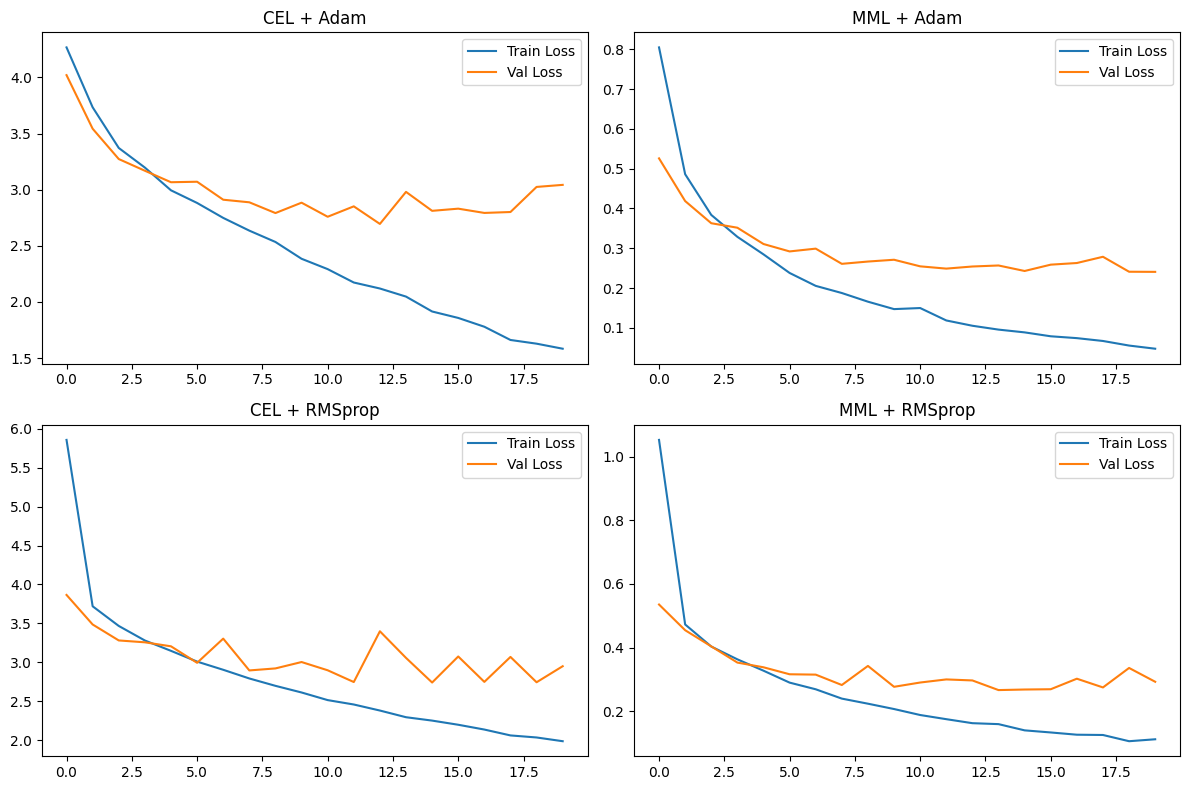

In [ ]:
# curvas de loss
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(train_losses_B1, label='Train Loss')
plt.plot(val_losses_B1, label='Val Loss')
plt.title('CEL + Adam')
plt.legend()
plt.subplot(2, 2, 2)
plt.plot(train_losses_B2, label='Train Loss')
plt.plot(val_losses_B2, label='Val Loss')
plt.title('MML + Adam')
plt.legend()
plt.subplot(2, 2, 3)
plt.plot(train_losses_B3, label='Train Loss')
plt.plot(val_losses_B3, label='Val Loss')
plt.title('CEL + RMSprop')
plt.legend()
plt.subplot(2, 2, 4)
plt.plot(train_losses_B4, label='Train Loss')
plt.plot(val_losses_B4, label='Val Loss')
plt.title('MML + RMSprop')
plt.legend()
plt.tight_layout()
plt.show()